# 策略 1：红利低波月调组合

按月末信号、下一交易日生效的口径复刻红利低波月调组合，并与中证红利低波全收益指数比较。请先按需运行 `download.ipynb`。

In [1]:
import os
import sys
from pathlib import Path

project_root = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
os.chdir(project_root)
source_root = project_root / "src"
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

In [2]:
from importlib.resources import files

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import yaml

from pyquant import calc_metrics, load_dataset
from strategies.div_low_vol.components import (
    calculate_div_low_vol_monthly_rebalanced_index,
)

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["PingFang SC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

## 配置与本地数据

In [3]:
with (
    files("strategies.div_low_vol")
    .joinpath("config.yaml")
    .open(encoding="utf-8") as stream
):
    config = yaml.safe_load(stream) or {}
start_date = pd.Timestamp(config["data"]["start_date"])
end_date = pd.Timestamp(config["data"]["end_date"])
lookback_date = start_date - pd.DateOffset(years=3)

price = load_dataset(
    "stock_daily",
    start=lookback_date.strftime("%Y-%m-%d"),
    end=end_date.strftime("%Y-%m-%d"),
)
dividends = load_dataset("dividend")
dividend_queries = load_dataset("dividend_queries")
shares = load_dataset("stock_profit_quarterly")
adjustment_factors = load_dataset("stock_adjust_factor")
adjustment_factor_coverage = load_dataset("stock_adjust_factor_coverage")
benchmark = (
    load_dataset(
        "csindex_daily",
        start=start_date.strftime("%Y-%m-%d"),
        end=end_date.strftime("%Y-%m-%d"),
        symbols=["H20269"],
    )
    .set_index("date")["close"]
    .rename("红利低波全收益指数")
)

## 月度调仓回测

In [4]:
strategy_index, constituents = calculate_div_low_vol_monthly_rebalanced_index(
    price,
    dividends,
    dividend_queries,
    shares,
    start_date,
    end_date,
    config,
    adjustment_factors,
    adjustment_factor_coverage,
)
benchmark_monthly_nav = benchmark.reindex(strategy_index.index).dropna()
curve = pd.concat(
    [
        strategy_index["total_return_index"].rename("红利低波月调组合"),
        benchmark_monthly_nav,
    ],
    axis=1,
).dropna()
curve = curve.div(curve.iloc[0])
returns = pd.concat(
    [
        strategy_index["total_return"].rename("红利低波月调组合"),
        benchmark_monthly_nav.pct_change(fill_method=None),
    ],
    axis=1,
).dropna()
rebalance_dates = constituents.index.get_level_values("effective_date").unique()
monthly_nav = curve.reindex(rebalance_dates).dropna()
monthly_nav = monthly_nav.div(monthly_nav.iloc[0])
monthly_nav.index.name = None

## 收益曲线

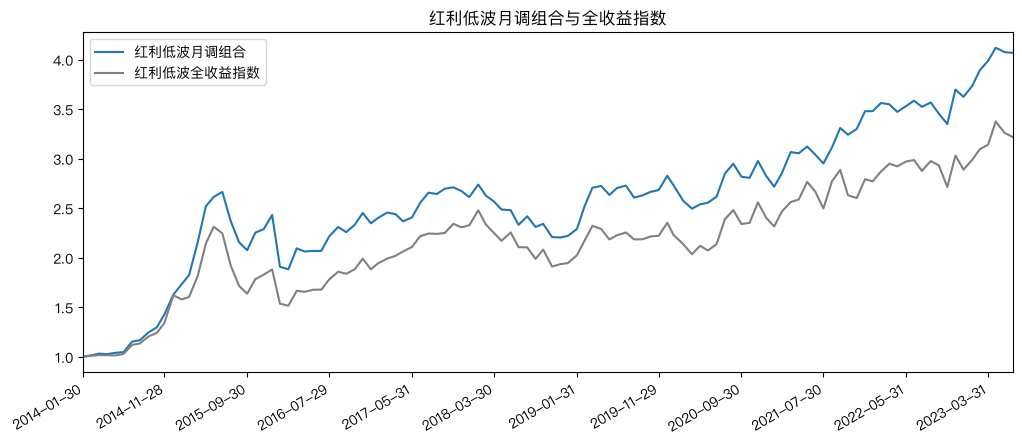

In [5]:
ax = monthly_nav.plot(
    figsize=(12, 5),
    title="红利低波月调组合与全收益指数",
    color={"红利低波月调组合": "C0", "红利低波全收益指数": "#808080"},
    style=["-", "-"],
)
ax.margins(x=0)
ax.set_xlabel("")
ax.set_xlim(monthly_nav.index.min(), monthly_nav.index.max())
ax.set_xticks(monthly_nav.index[::10])
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.figure.autofmt_xdate()
plt.show()

## 绩效对比

信息比率按研报表格口径计算为年化收益除以年化波动；月度胜率为月末净值收益大于零的比例。

In [6]:
def summarize_performance(monthly_returns):
    metrics = calc_metrics(monthly_returns, periods_per_year=12)
    return pd.Series(
        {
            "年化收益": metrics["annual_return"],
            "年化波动": metrics["annual_vol"],
            "信息比率": metrics["sharpe"],
            "月度胜率": (monthly_returns > 0).mean(),
            "最大回撤": -metrics["max_drawdown"],
        }
    )


performance = returns.apply(summarize_performance)
percentage_rows = ["年化收益", "年化波动", "月度胜率", "最大回撤"]
performance.style.format(
    "{:.2%}",
    subset=pd.IndexSlice[percentage_rows, :],
).format(
    "{:.2f}",
    subset=pd.IndexSlice["信息比率", :],
)

,红利低波月调组合,红利低波全收益指数
年化收益,16.07%,13.22%
年化波动,18.27%,20.10%
信息比率,0.88,0.66
月度胜率,61.95%,61.95%
最大回撤,29.32%,34.48%
